# Softmax Regression / Multinomial Logistic Regression

- **Softmax Regression** is a generalization of logistic regression to multiple classes. It is used when the dependent variable (target) is categorical with more than two classes.

- Now, the data have 3 classes for placement status: Yes, No, Optout. 
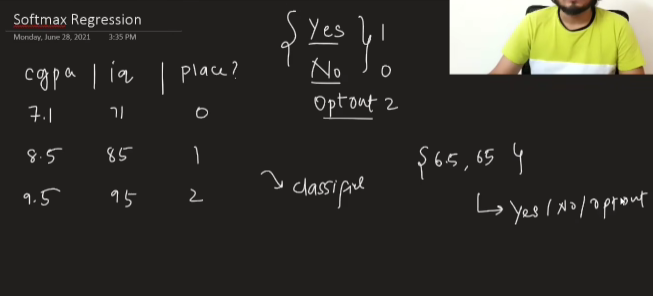

# Softmax Function

$$
\sigma(\mathbf{z})_j = \frac{e^{z_j}}{\sum_{k=1}^K e^{z_k}}
$$

- where $ z_j $ is the input to the softmax function for class $ j $, and $ K $ is the total number of classes.

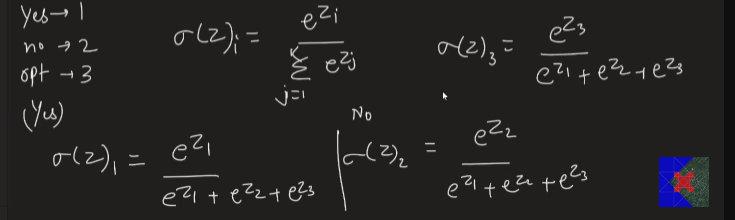

- **So, softmax function mei agar aap $z$ value provide krte ho for any particular class, toh wo aapko us class ke liye probability dega. Aur ye probability 0 aur 1 ke beech hoti hai, aur sabhi classes ke probabilities ka sum 1 hota hai.**

- Just like for binary LR, sigmoid function used to give us the probability of the positive class, in softmax regression, the softmax function gives us the probabilities for each class in a multi-class classification problem.

# Training Softmax Regression Intuition

- Avhi jo example de rhe h wo exactly sklearn mei nhi hots, this is for understanding the intuition behind training softmax regression.

1. We will one-hot encode the target variable (placement status), as it has 3 classes. So, we will have 3 columns for the target variable, each column representing one class (Yes, No, Optout).

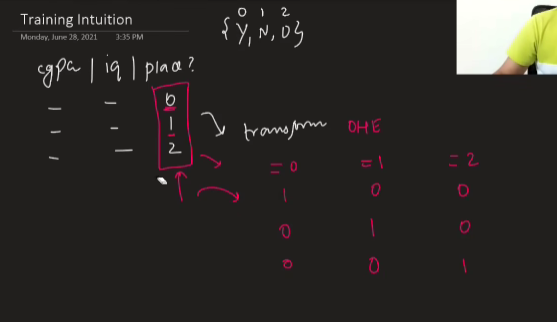

2. Now we will create 3 separate dataset out of the original dataset, each dataset will be used to train a binary logistic regression model for one class

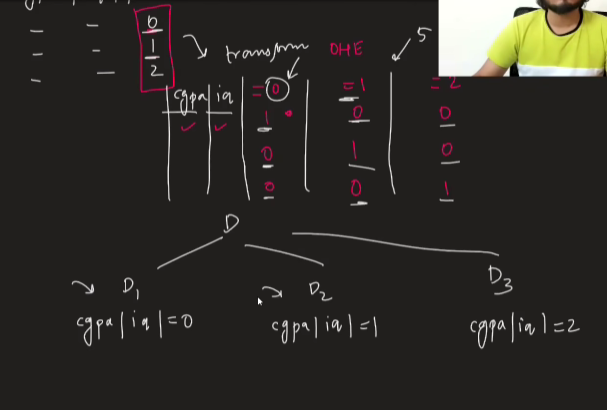

- So in a way we converted  multi-class classification problem into multiple binary classification problems.

3. Train 3 different logistic regression models, one for each class. Each model will predict the probability of the target variable being in that class.

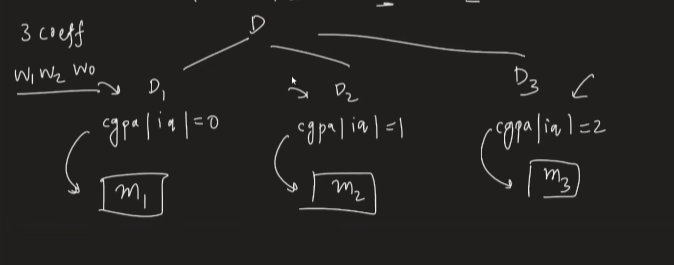

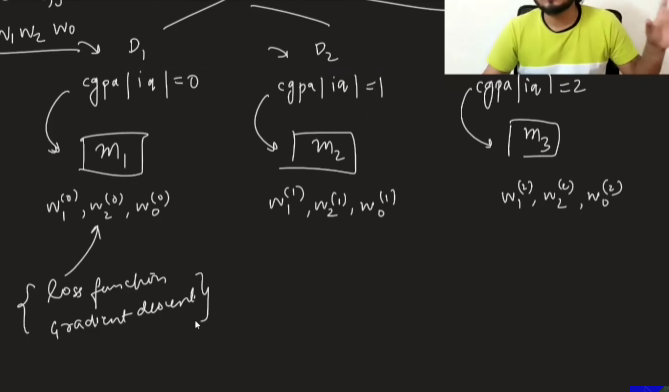

- So we will get 9 different coefficients (3 for each model)

# Prediction

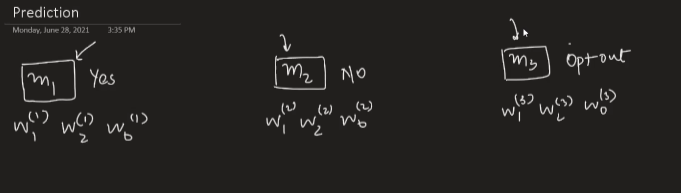

- So in the above pic, for model 1 (M1), it gives the probability of the target variable being Yes (1) or No/Optout (0), for model 2 (M2), it gives the probability of the target variable being No (1) or Yes/Optout (0), and for model 3 (M3), it gives the probability of the target variable being in class Optout (1) or Yes/No (0).

1. Calculate the linear combination of the input features and the coefficients for each model to get the $(z)$ values for each class.

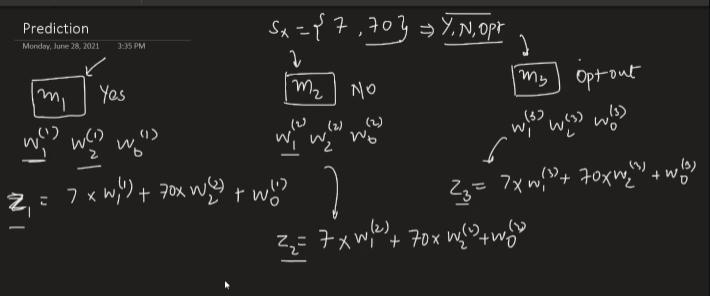

2. Now apply softmax function to these $z$ values to get the probabilities for each class.

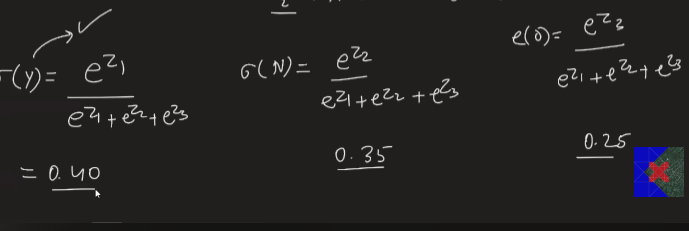

- As probability of Yes is highest, we will predict the target variable as Yes for this particular data point.

## Downside of this approach:

- We have to train the same number of models as the number of classes, which can be computationally expensive if we have a large number of classes.

- So, we change the loss function of Logistic Regression in such a way that we can train a single model for multi-class classification, and this is exactly **sklearn's Softmax Regression.**


# Loss Function for Softmax Regression

$$
\mathcal{L} = - \frac{1}{m} \sum_{i=1}^m \sum_{k=1}^K y_{k}^{(i)} \log(\hat{y}_{k}^{(i)})
$$

- Inside summation is for each class $k$ and for each data point $i$, we are calculating the contribution to the loss based on the true label and the predicted probability for that class. The outer summation averages this loss over all data points in the dataset.

- where $m$ is the number of rows in the dataset, $K$ is the number of classes, $y_{k}^{(i)}$ is the true label for class $k$ for the $i$-th data point (1 if the true class is $k$, otherwise 0), and $\hat{y}_{k}^{(i)}$ is the predicted probability for class $k$ for the $i$-th data point.

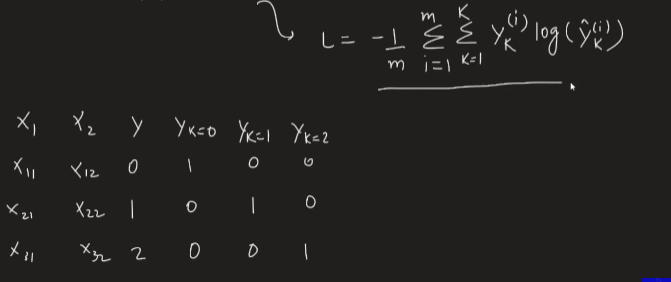

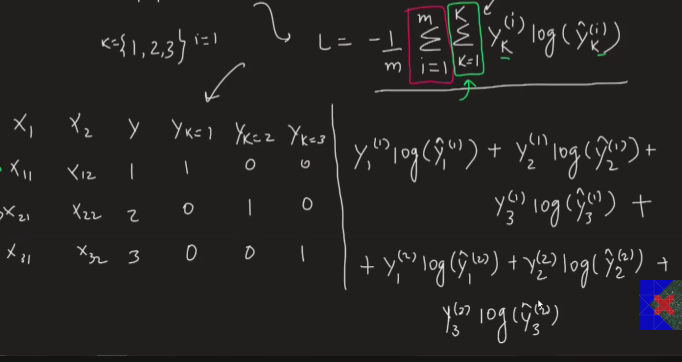
(changed the class label to 1,2,3 for better understanding don't worry about it)

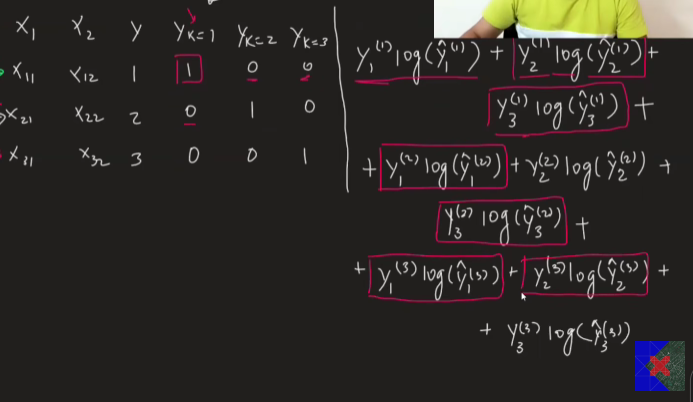

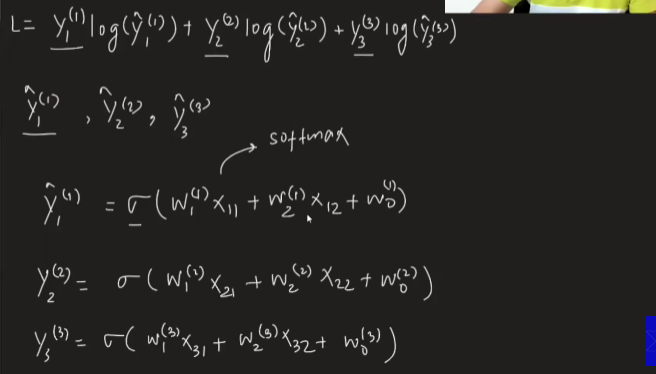

- While applying gradient descent we have to calculate 9 partial derivatives {as there are 9 coefficients} and update the coefficients accordingly. {number of coefficients = number of features * number of rows in the dataset}

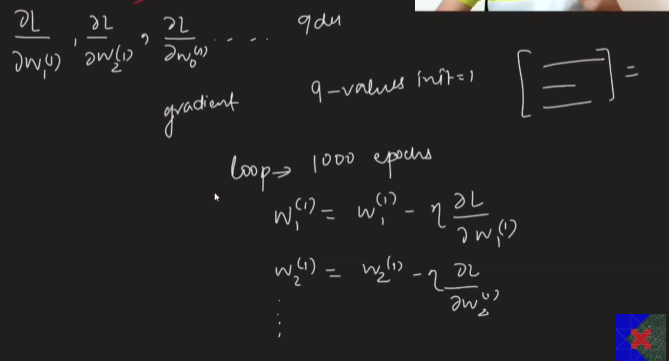

In [1]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('iris')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


- Convert text values to numeric values using label encoding 

In [4]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
df = df[['sepal_length','petal_length','species']]

In [7]:
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [19]:
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [8]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
clf = LogisticRegression(solver='lbfgs', max_iter=1000) # For multi-class classification, we can use the 'lbfgs' solver which supports it.

In [12]:
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
y_pred = clf.predict(X_test)

In [14]:
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [15]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [ ]:
# prediction
query = np.array([[3.4,2.7]])
clf.predict_proba(query) # it tells the probability of the query belonging to each class. 

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [17]:
clf.predict(query)

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

c:\Users\Kaushik Mandal\.virtualenvs\ClassicalML-_wR1sNSC\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


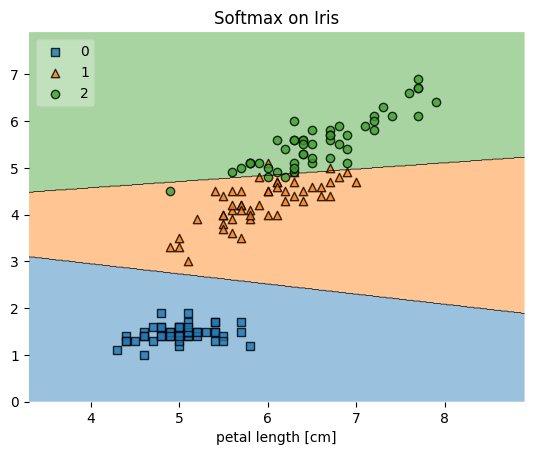

In [18]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, clf, legend=2)

# Adding axes annotations
plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('Softmax on Iris')

plt.show()